In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def compare_anomaly_models(*model_dfs, id_column='TestKey'):
    df_combined = pd.DataFrame({id_column: model_dfs[0][0][id_column]})
    
    number_of_anomalies = 0
    model_names = []
    for df, model_name in model_dfs:
        number_of_anomalies +=1 
        model_names.append(model_name)
        df_combined = df_combined.merge(
            df[[id_column, 'is_anomaly']],
            on=id_column,
            suffixes=('', f'_{model_name}')
        )
        df_combined = df_combined.rename(columns={'is_anomaly': f'{model_name}_anomaly'})
    
    anomaly_columns = [col for col in df_combined.columns if col.endswith('_anomaly')]
    df_combined['anomaly_count'] = df_combined[anomaly_columns].sum(axis=1)

    df_combined['anomaly_score'] = df_combined['anomaly_count'] / number_of_anomalies 
    
    return df_combined

## Test 
### import csv's

In [3]:
df_copod = pd.read_csv('./csv/copod.csv')
df_ecod = pd.read_csv('./csv/ecod.csv')
df_i_forest = pd.read_csv('./csv/i_forest.csv')
df_lof = pd.read_csv('./csv/lof.csv')
df_abod = pd.read_csv('./csv/abod.csv')
# df_neighbours = pd.read_csv('./csv/neighbours.csv')

### Compare and anomaly score

In [4]:
df_anomalies = compare_anomaly_models(
    (df_copod, 'copod'), 
    (df_ecod, 'ecod'), 
    (df_i_forest, 'i_forest'),
    (df_lof, 'lof'),
    (df_abod, 'abod'),
    # (df_neighbours, 'neighbours'),
    id_column='TestKey'
)
df_anomalies.head()

,TestKey,copod_anomaly,ecod_anomaly,i_forest_anomaly,lof_anomaly,abod_anomaly,anomaly_count,anomaly_score
0,251025,1,0,0,0,0,1,0.2
1,251170,1,0,0,0,1,2,0.4
2,251171,1,0,0,0,0,1,0.2
3,251172,1,0,0,0,1,2,0.4
4,251173,1,0,0,0,0,1,0.2


### is_anomaly

In [5]:
np.mean(df_anomalies.anomaly_score)

0.04582517586108875

In [8]:
top_percent = 1  # top 1% 
threshold = np.percentile(df_anomalies['anomaly_score'], 100 - top_percent)
print('threshold:', threshold)
df_anomalies['is_anomaly'] = df_anomalies['anomaly_score'] >= threshold

df_anomalies.head()

threshold: 0.4


,TestKey,copod_anomaly,ecod_anomaly,i_forest_anomaly,lof_anomaly,abod_anomaly,anomaly_count,anomaly_score,is_anomaly
0,251025,1,0,0,0,0,1,0.2,False
1,251170,1,0,0,0,1,2,0.4,True
2,251171,1,0,0,0,0,1,0.2,False
3,251172,1,0,0,0,1,2,0.4,True
4,251173,1,0,0,0,0,1,0.2,False


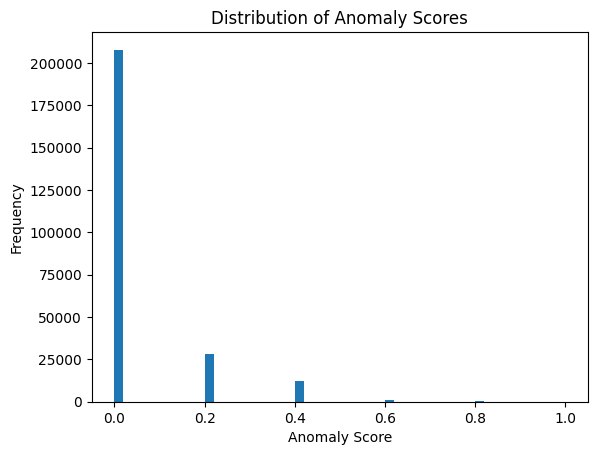

In [6]:
plt.hist(df_anomalies['anomaly_score'], bins=50)
plt.title('Distribution of Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.show()

In [9]:
def calculate_anomaly_threshold(df, column='anomaly_score', multiplier=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    threshold = Q3 + (multiplier * IQR)
    return threshold

# Calculate the threshold
threshold = calculate_anomaly_threshold(df_anomalies)
print('threshold:', threshold)
# Apply the threshold to create the is_anomaly column
df_anomalies['is_anomaly'] = df_anomalies['anomaly_score'] > threshold

# Calculate the percentile of the threshold
percentile = (df_anomalies['anomaly_score'] <= threshold).mean() * 100

print(f"The threshold corresponds to the {percentile:.2f}th percentile")
df_anomalies.head()

threshold: 0.0
The threshold corresponds to the 83.21th percentile


,TestKey,copod_anomaly,ecod_anomaly,i_forest_anomaly,lof_anomaly,abod_anomaly,anomaly_count,anomaly_score,is_anomaly
0,251025,1,0,0,0,0,1,0.2,True
1,251170,1,0,0,0,1,2,0.4,True
2,251171,1,0,0,0,0,1,0.2,True
3,251172,1,0,0,0,1,2,0.4,True
4,251173,1,0,0,0,0,1,0.2,True


### Store in DimTestAnomalies

In [ ]:
# df_anomalies.to_csv("../../decoded_data/MDQ/DimTestAnomalies.csv", index=False)
# df_anomalies.head()

,copod_anomaly,ecod_anomaly,i_forest_anomaly,lof_anomaly,abod_anomaly,anomaly_count,anomaly_score
TestKey,,,,,,,
251025,1,1,0,0,0,2,0.4
251170,1,1,1,0,1,4,0.8
251171,1,1,0,0,0,2,0.4
251172,1,1,0,0,1,3,0.6
251173,1,1,0,0,0,2,0.4
